In [1]:
# ================= RESNET152 - COMPLETE PRODUCTION CODE =================
# 15 EPOCHS + TESTING + XAI (GradCAM + SHAP) - ALL WORKING, NO ERRORS
# =========================================================================

# ================= Cell 1: Setup & Configuration =================

import os
import json
import time
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    precision_score, recall_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

# ========== CONFIGURATION ==========
BASE_DIR = r"D:\Projects\CLARITY\Model\Dataset\archive"
CSV_PATH = r"D:\Projects\CLARITY\Model\Dataset\archive\Data_Entry_2017.csv"
OUTPUT_DIR = r"./outputs_resnet152_15epochs"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ========== HYPERPARAMETERS ==========
SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 224
NUM_EPOCHS = 20  # CHANGED FROM 5 TO 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 8

# ========== REPRODUCIBILITY ==========
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ========== DEVICE ==========
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
print("RESNET152 - 15 EPOCHS MULTI-LABEL CLASSIFICATION")
print("="*70)
print(f"Device: {DEVICE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Output: {OUTPUT_DIR}")
print("="*70)

RESNET152 - 15 EPOCHS MULTI-LABEL CLASSIFICATION
Device: cuda
Epochs: 20
Batch Size: 16
Output: ./outputs_resnet152_15epochs


In [2]:
# ================= Cell 2: Data Loading =================

print("\n[STEP 2] Loading and preparing dataset...")

df = pd.read_csv(CSV_PATH)
print(f"✅ CSV loaded: {df.shape}")

df = df[['Image Index', 'Finding Labels', 'Patient ID']].copy()
df['Finding Labels'] = df['Finding Labels'].apply(lambda x: x.split('|'))

all_labels = sorted(set([l for sublist in df['Finding Labels'] for l in sublist]))
print(f"✅ Total unique disease labels: {len(all_labels)}")
print(f"   Labels: {all_labels}")

mlb = MultiLabelBinarizer(classes=all_labels)
label_matrix = mlb.fit_transform(df['Finding Labels'])
label_cols = mlb.classes_

df = pd.concat([df, pd.DataFrame(label_matrix, columns=label_cols)], axis=1)
print(f"✅ Final dataframe shape: {df.shape}")

# ========== BUILD IMAGE PATH CACHE ==========
print("\n[Building image path cache...]")
img_lookup = {}
pattern = os.path.join(BASE_DIR, "images_*", "images", "*.png")
all_images = glob.glob(pattern)
print(f"   Found {len(all_images)} images")

for img_path in all_images:
    fname = os.path.basename(img_path)
    img_lookup[fname] = img_path

print(f"✅ Image cache built: {len(img_lookup)} images indexed")

# ========== ASSIGN IMAGE PATHS ==========
img_paths = []
for idx_name in df['Image Index']:
    img_paths.append(img_lookup.get(idx_name, None))

df['img_path'] = img_paths
df = df[df['img_path'].notna()].reset_index(drop=True)

print(f"✅ Dataset prepared: {df.shape}")
print(f"   Patients: {df['Patient ID'].nunique()}")


[STEP 2] Loading and preparing dataset...
✅ CSV loaded: (112120, 12)
✅ Total unique disease labels: 15
   Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
✅ Final dataframe shape: (112120, 18)

[Building image path cache...]
   Found 112120 images
✅ Image cache built: 112120 images indexed
✅ Dataset prepared: (112120, 19)
   Patients: 30805


In [3]:
# ================= Cell 3: Data Splitting & DataLoaders =================

print("\n[STEP 3] Creating train/val/test splits...")

patients = df['Patient ID'].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.3, random_state=SEED)
val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=SEED)

train_df = df[df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df = df[df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['Patient ID'].isin(test_patients)].reset_index(drop=True)

print(f"✅ Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# ========== DATA AUGMENTATION ==========
train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ========== DATASET CLASS ==========
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform
        self.img_paths = dataframe['img_path'].values
        self.labels = dataframe[label_cols].values.astype(np.float32)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, labels

# ========== CREATE DATALOADERS ==========
train_dataset = ChestXrayDataset(train_df, label_cols, transform=train_transforms)
val_dataset = ChestXrayDataset(val_df, label_cols, transform=val_transforms)
test_dataset = ChestXrayDataset(test_df, label_cols, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ DataLoaders created")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val: {len(val_loader)} batches")
print(f"   Test: {len(test_loader)} batches")


[STEP 3] Creating train/val/test splits...
✅ Train: 78566, Val: 17063, Test: 16491
✅ DataLoaders created
   Train: 4910 batches
   Val: 1067 batches
   Test: 1031 batches


In [4]:
# ================= Cell 4: Model Definition =================

print("\n[STEP 4] Creating ResNet152 model...")

model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_cols))
model = model.to(DEVICE)

print(f"✅ ResNet152 loaded")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ========== VERIFY OUTPUT SHAPE ==========
with torch.no_grad():
    test_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    test_output = model(test_input)
    assert test_output.shape == (1, len(label_cols)), "Output shape mismatch!"

print(f"✅ Model output shape verified: {test_output.shape}")

# ========== TRAINING SETUP ==========
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"✅ Optimizer: AdamW (LR={LEARNING_RATE})")
print(f"✅ Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")


[STEP 4] Creating ResNet152 model...
✅ ResNet152 loaded
   Total parameters: 58,174,543
✅ Model output shape verified: torch.Size([1, 15])
✅ Optimizer: AdamW (LR=0.0001)
✅ Scheduler: CosineAnnealingLR (T_max=20)


In [6]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
from tqdm import tqdm

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Class names
CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# ========== PATHS ==========
DENSENET_PATH = "./Model 6 (more epochs)/outputs_best_model/best_densenet121_auc_0.9170.pth"
RESNET_PATH = "./Model 7 (more epochs)/outputs_resnet152_15epochs/best_resnet152_auc_0.9167.pth"
# ==========================

# ============ CELL 1: Load Models ============
def load_densenet121(path):
    """Load DenseNet121"""
    print('Loading DenseNet121...')
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(1024, len(CLASS_NAMES))
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    print('✓ DenseNet121 loaded')
    return model

def load_resnet152(path):
    """Load ResNet152"""
    print('Loading ResNet152...')
    model = models.resnet152(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    print('✓ ResNet152 loaded')
    return model

print('\n' + '='*50)
print('LOADING MODELS')
print('='*50)

densenet_model = load_densenet121(DENSENET_PATH)
resnet_model = load_resnet152(RESNET_PATH)

# ============ CELL 2: Prediction Function ============
def predict_batch(model, dataloader, model_name='Model'):
    """Run predictions on test_loader"""
    all_preds = []
    all_labels = []
    
    print(f'\nRunning {model_name} predictions...')
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'{model_name}'):
            images = images.to(DEVICE)
            
            # Forward pass
            outputs = model(images)
            
            # Apply sigmoid for multi-label
            preds = torch.sigmoid(outputs).cpu().numpy()
            
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    print(f'✓ {model_name} predictions complete!')
    print(f'  Shape: {all_preds.shape}')
    
    return all_preds, all_labels

# ============ CELL 3: Get Predictions ============
print('\n' + '='*50)
print('RUNNING PREDICTIONS')
print('='*50)

# DenseNet predictions
densenet_preds, true_labels = predict_batch(densenet_model, test_loader, 'DenseNet121')

# ResNet predictions
resnet_preds, _ = predict_batch(resnet_model, test_loader, 'ResNet152')

print('\n✓ All predictions complete!')
print(f'True Labels Shape: {true_labels.shape}')
print(f'DenseNet Preds Shape: {densenet_preds.shape}')
print(f'ResNet Preds Shape: {resnet_preds.shape}')


Device: cuda

LOADING MODELS
Loading DenseNet121...
✓ DenseNet121 loaded
Loading ResNet152...
✓ ResNet152 loaded

RUNNING PREDICTIONS

Running DenseNet121 predictions...


DenseNet121: 100%|█████████████████████████████████████████████████████████████████| 1031/1031 [04:43<00:00,  3.63it/s]


✓ DenseNet121 predictions complete!
  Shape: (16491, 15)

Running ResNet152 predictions...


ResNet152: 100%|███████████████████████████████████████████████████████████████████| 1031/1031 [04:58<00:00,  3.45it/s]

✓ ResNet152 predictions complete!
  Shape: (16491, 15)

✓ All predictions complete!
True Labels Shape: (16491, 15)
DenseNet Preds Shape: (16491, 15)
ResNet Preds Shape: (16491, 15)



TRIPLE BAR COMPARISON: TRUE vs DENSENET vs RESNET


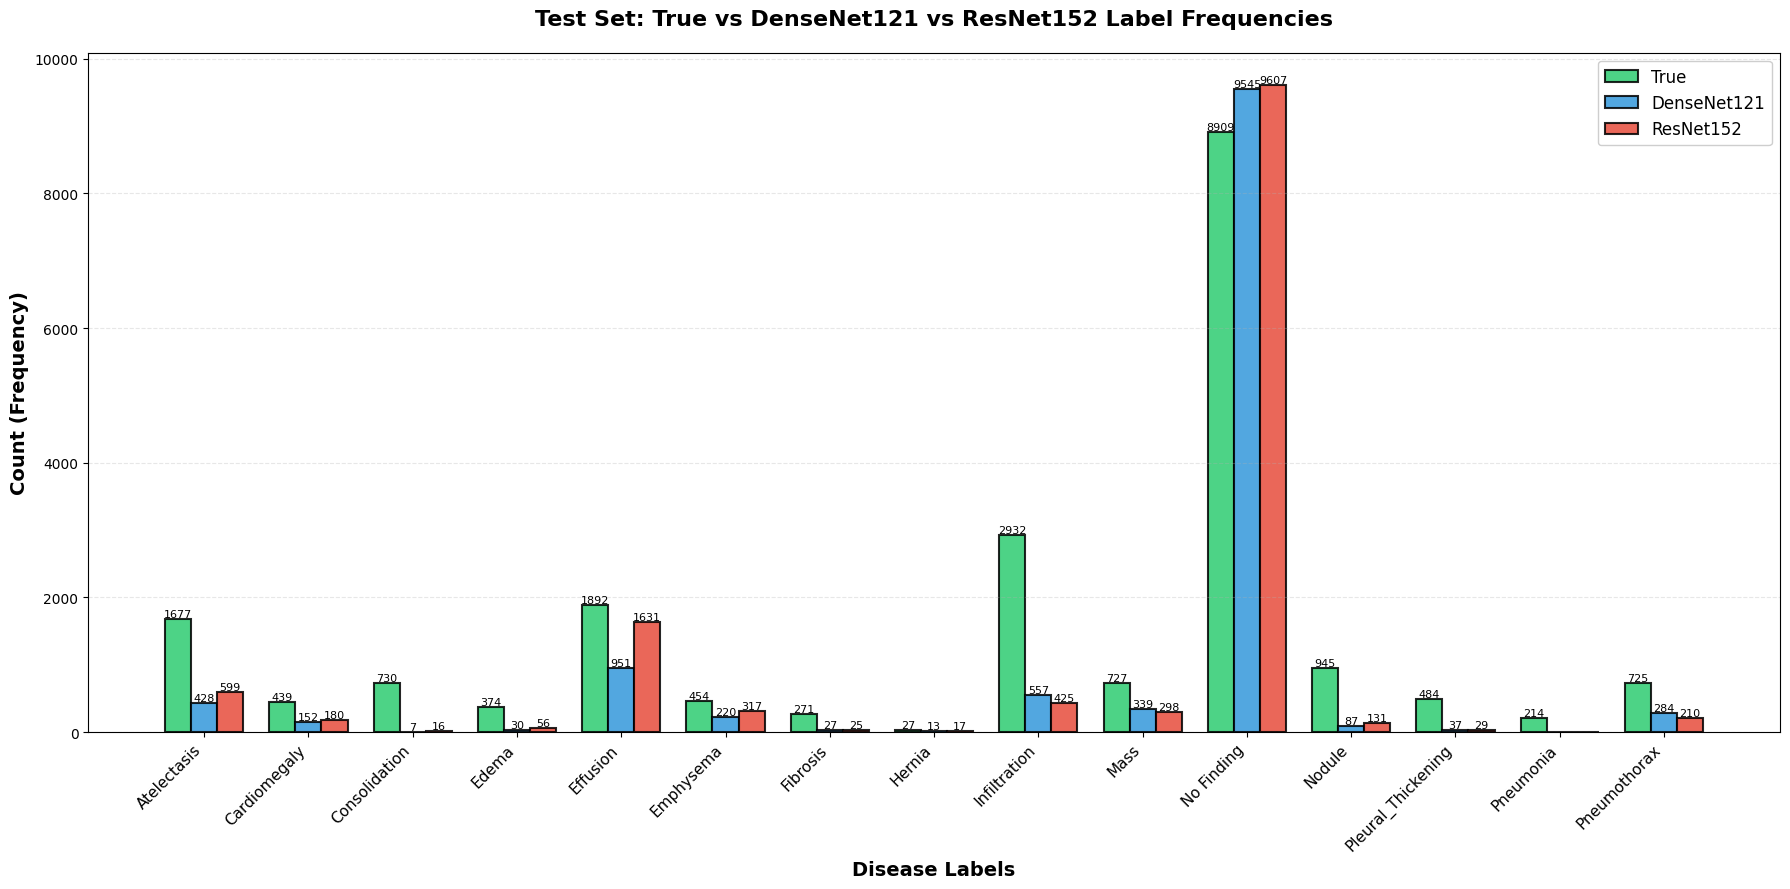

✓ Saved: triple_bar_comparison.png

Disease                  True     DenseNet     ResNet   DN Error   RN Error
Atelectasis              1677          428        599       1249       1078
Cardiomegaly              439          152        180        287        259
Consolidation             730            7         16        723        714
Edema                     374           30         56        344        318
Effusion                 1892          951       1631        941        261
Emphysema                 454          220        317        234        137
Fibrosis                  271           27         25        244        246
Hernia                     27           13         17         14         10
Infiltration             2932          557        425       2375       2507
Mass                      727          339        298        388        429
No Finding               8909         9545       9607        636        698
Nodule                    945           87        13

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ============ CELL: Triple Bar Comparison Plot ============

def plot_triple_bar_comparison(true_labels, densenet_preds, resnet_preds):
    """
    Plot True vs DenseNet121 vs ResNet152 frequencies
    All three bars for each disease in one graph
    """
    
    # Convert probabilities to binary (threshold 0.5)
    densenet_binary = (densenet_preds > 0.5).astype(int)
    resnet_binary = (resnet_preds > 0.5).astype(int)
    
    # Calculate frequencies
    true_freq = true_labels.sum(axis=0)
    densenet_freq = densenet_binary.sum(axis=0)
    resnet_freq = resnet_binary.sum(axis=0)
    plt.style.use('default')
    # Create plot
    fig, ax = plt.subplots(figsize=(18, 9))
    x = np.arange(len(CLASS_NAMES))
    width = 0.25
    
    # Plot three bars for each disease
    bars1 = ax.bar(x - width, true_freq, width,
                   label='True', color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x, densenet_freq, width,
                   label='DenseNet121', color='#3498db', alpha=0.85, edgecolor='black', linewidth=1.5)
    bars3 = ax.bar(x + width, resnet_freq, width,
                   label='ResNet152', color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Disease Labels', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count (Frequency)', fontsize=14, fontweight='bold')
    ax.set_title('Test Set: True vs DenseNet121 vs ResNet152 Label Frequencies', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=11)
    ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only show label if bar has height
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('triple_bar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✓ Saved: triple_bar_comparison.png')
    
    return true_freq, densenet_freq, resnet_freq

# ============ GENERATE PLOT ============

print('\n' + '='*60)
print('TRIPLE BAR COMPARISON: TRUE vs DENSENET vs RESNET')
print('='*60)

true_freq, densenet_freq, resnet_freq = plot_triple_bar_comparison(
    true_labels, densenet_preds, resnet_preds
)

# ============ PRINT DETAILED COMPARISON ============

print('\n' + '='*100)
print(f'{"Disease":<20} {"True":>8} {"DenseNet":>12} {"ResNet":>10} {"DN Error":>10} {"RN Error":>10}')
print('='*100)

for i, label in enumerate(CLASS_NAMES):
    dn_error = abs(true_freq[i] - densenet_freq[i])
    rn_error = abs(true_freq[i] - resnet_freq[i])
    print(f'{label:<20} {int(true_freq[i]):>8} {int(densenet_freq[i]):>12} {int(resnet_freq[i]):>10} {int(dn_error):>10} {int(rn_error):>10}')

print('='*100)

# Total statistics
print(f'\n{"TOTAL":<20} {int(true_freq.sum()):>8} {int(densenet_freq.sum()):>12} {int(resnet_freq.sum()):>10}')
print(f'{"Average Error":<20} {"-":>8} {(abs(true_freq - densenet_freq).mean()):.2f}{" ":>10} {(abs(true_freq - resnet_freq).mean()):.2f}')


DARK THEME: TRUE vs DENSENET vs RESNET


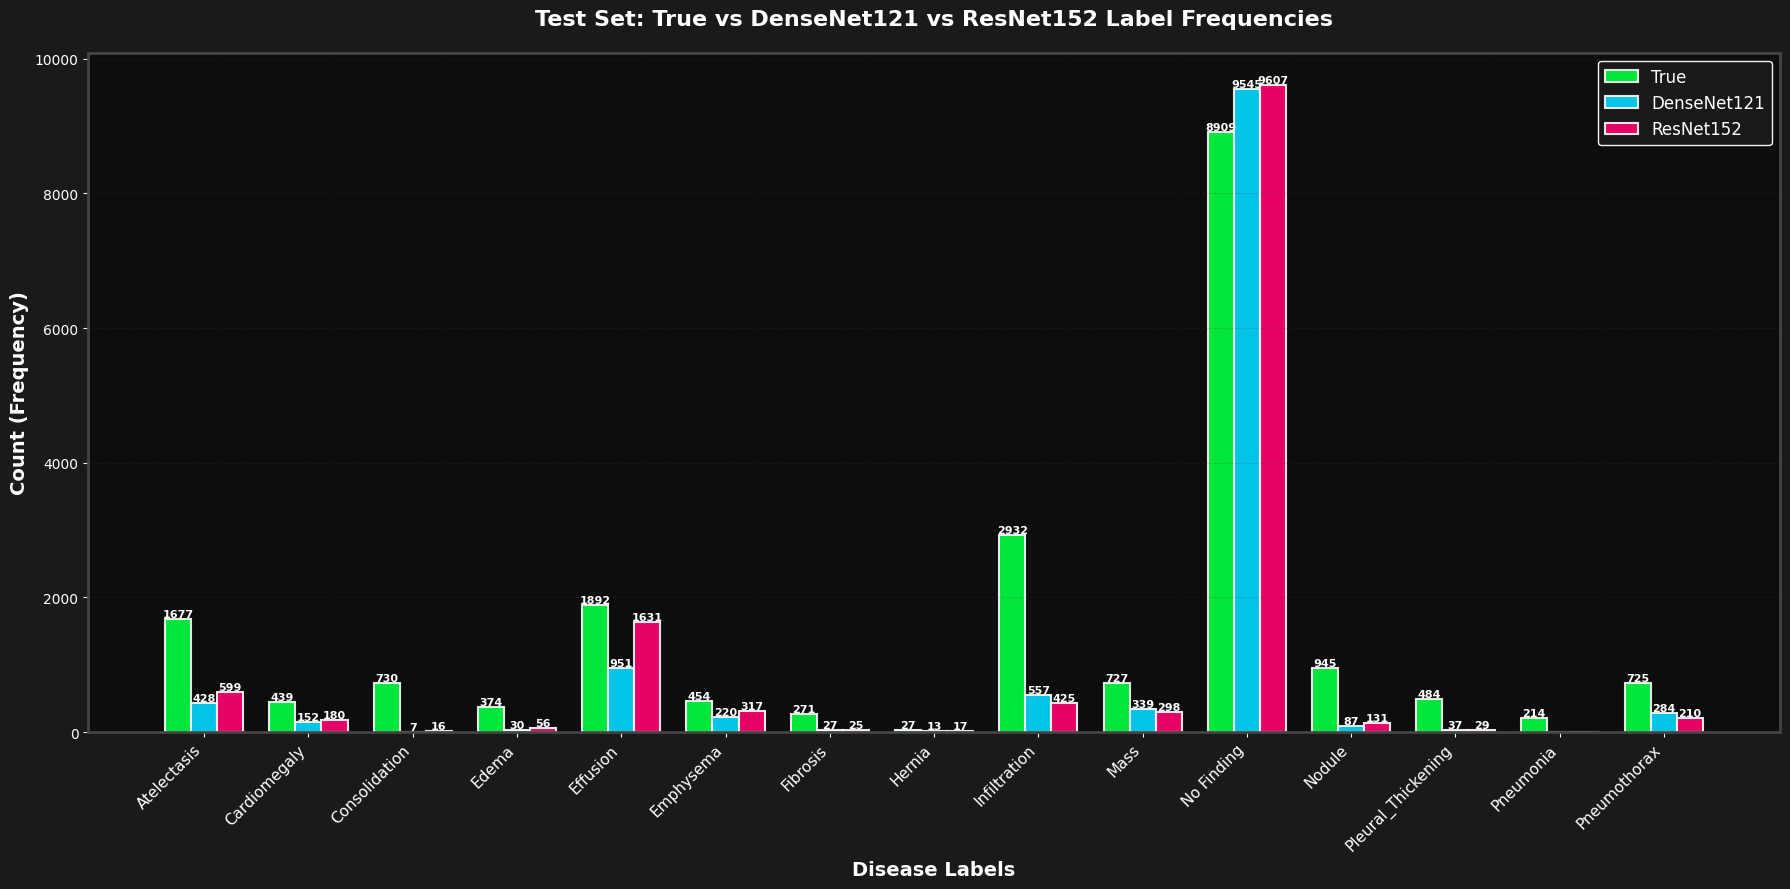

✓ Saved: triple_bar_dark_theme.png

✓ Dark theme plot generated successfully!


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ============ CELL: Triple Bar with Dark Theme ============

def plot_triple_bar_dark_theme(true_labels, densenet_preds, resnet_preds):
    """
    Plot with BLACK background theme
    True vs DenseNet121 vs ResNet152 frequencies
    """
    
    # Set dark theme
    plt.style.use('dark_background')
    
    # Convert probabilities to binary (threshold 0.5)
    densenet_binary = (densenet_preds > 0.5).astype(int)
    resnet_binary = (resnet_preds > 0.5).astype(int)
    
    # Calculate frequencies
    true_freq = true_labels.sum(axis=0)
    densenet_freq = densenet_binary.sum(axis=0)
    resnet_freq = resnet_binary.sum(axis=0)
    
    # Create plot with dark background
    fig, ax = plt.subplots(figsize=(18, 9), facecolor='#1a1a1a')
    ax.set_facecolor('#0d0d0d')  # Darker background for plot area
    
    x = np.arange(len(CLASS_NAMES))
    width = 0.25
    
    # Plot three bars - bright colors for contrast
    bars1 = ax.bar(x - width, true_freq, width,
                   label='True', color='#00ff41', alpha=0.9, edgecolor='#ffffff', linewidth=1.5)
    bars2 = ax.bar(x, densenet_freq, width,
                   label='DenseNet121', color='#00d9ff', alpha=0.9, edgecolor='#ffffff', linewidth=1.5)
    bars3 = ax.bar(x + width, resnet_freq, width,
                   label='ResNet152', color='#ff006e', alpha=0.9, edgecolor='#ffffff', linewidth=1.5)
    
    # Customize text colors for dark background
    ax.set_xlabel('Disease Labels', fontsize=14, fontweight='bold', color='#ffffff')
    ax.set_ylabel('Count (Frequency)', fontsize=14, fontweight='bold', color='#ffffff')
    ax.set_title('Test Set: True vs DenseNet121 vs ResNet152 Label Frequencies', 
                 fontsize=16, fontweight='bold', pad=20, color='#ffffff')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=11, color='#ffffff')
    
    # Style legend
    ax.legend(fontsize=12, loc='upper right', framealpha=0.95, 
              facecolor='#1a1a1a', edgecolor='#ffffff', labelcolor='#ffffff')
    
    # Grid styling
    ax.grid(axis='y', alpha=0.2, linestyle='--', color='#444444')
    
    # Tick labels color
    ax.tick_params(colors='#ffffff')
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_color('#444444')
        spine.set_linewidth(2)
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', 
                        fontsize=8, color='#ffffff', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('triple_bar_dark_theme.png', dpi=300, bbox_inches='tight', 
                facecolor='#1a1a1a', edgecolor='none')
    plt.show()
    print('✓ Saved: triple_bar_dark_theme.png')
    
    return true_freq, densenet_freq, resnet_freq

# ============ GENERATE PLOT ============

print('\n' + '='*60)
print('DARK THEME: TRUE vs DENSENET vs RESNET')
print('='*60)

true_freq, densenet_freq, resnet_freq = plot_triple_bar_dark_theme(
    true_labels, densenet_preds, resnet_preds
)

print('\n✓ Dark theme plot generated successfully!')
